# Project Title: Open-Vocabulary Video Target Tracking Using SAM 3
# Student Name: Sadeq Yazdani
# Student ID: 4043614037

# Hardware Check & GPU Status

In [1]:
!nvidia-smi-L
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


/bin/bash: line 1: nvidia-smi-L: command not found
CUDA available: True
Device: Tesla T4


# Setup and Dependencies Installation

In [2]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .
!pip install -e ".[notebooks]"
%cd /content

Cloning into 'sam3'...
remote: Enumerating objects: 1187, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1187 (delta 1), reused 0 (delta 0), pack-reused 1180 (from 3)
Receiving objects: 100% (1187/1187), 60.37 MiB | 27.16 MiB/s, done.
Resolving deltas: 100% (346/346), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 79.6 MB/s eta 0:00:00
  Building editable for sam3 (pyproject.toml) ... 

Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 99.5 MB

# Mounting Google Drive & Download weights of sam3

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ckpt = "/content/drive/MyDrive/sam3.pt"

Mounted at /content/drive


# Video Input Configuration

In [2]:
video_path = "/content/data/ball.mp4"

# Model Initialization and Prompting

In [3]:
!pip install triton

In [4]:
from sam3.model_builder import build_sam3_video_predictor

TEXT_PROMPT = "green ball"

video_predictor = build_sam3_video_predictor(
    bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz",
    checkpoint_path=ckpt,)

resp = video_predictor.handle_request(
    request=dict(type="start_session",resource_path=video_path,))
session_id = resp["session_id"]

resp = video_predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=0,
        text=TEXT_PROMPT,))

print("Session:", session_id, "| prompt:", TEXT_PROMPT)


/content/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-07-18 17:12:42,387 1612 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-07-18 17:12:42,388 1612 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-07-18 17:12:42,389 1612 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-07-18 17:12:53,468 1612 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-07-18 17:14:19,572 1612 sam3_video_predictor.py: 1

Session: b61ebfb0-2f45-4d12-b90d-c0f162053f2f | prompt: green ball


# Mask Extraction and Centroid Calculation

In [5]:
import numpy as np
import cv2

def mask_to_binary(mask):
    m = mask
    if isinstance(m, dict):
        if "masks" in m:
            m = m["masks"]
        elif "logits" in m:
            m = m["logits"]
        else:
            for key, value in m.items():
                if hasattr(value, "shape"):
                    m = value
                    break

    if hasattr(m, "detach"):
        m = m.detach().cpu().numpy()

    m = np.asarray(m)

    if m.size == 0:
        return np.zeros((2, 2), dtype=np.uint8)

    m = np.squeeze(m)

    if m.ndim < 2 or m.size == 0:
        return np.zeros((2, 2), dtype=np.uint8)

    if m.ndim > 2:
        m = m[0]

    if m.dtype != bool:
        m = m > 0.0

    return (m.astype(np.uint8)) * 255

trajectory = []
frame_masks = {}
stream_generator = video_predictor.handle_stream_request(
request=dict(type="propagate_in_video", session_id=session_id)
)

for frame_result in stream_generator:
    frame_idx = frame_result["frame_index"]
    outputs = frame_result.get("outputs", {})
    masks = []
    if isinstance(outputs, dict):
        for obj_id, mask in outputs.items():
            masks.append(mask)
    elif isinstance(outputs, list):
        masks = outputs
    elif "masks" in frame_result:
        masks = frame_result["masks"]

    if not masks:
        continue

    binary_masks = [mask_to_binary(m) for m in masks]
    areas = [int((bm > 0).sum()) for bm in binary_masks]

    if not areas or max(areas) == 0:
        continue

    best = int(np.argmax(areas))
    binary_mask = binary_masks[best]
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)
    frame_masks[frame_idx] = clean_mask

    M = cv2.moments(clean_mask, binaryImage=True)
    if M["m00"] == 0:
        continue

    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    trajectory.append((frame_idx, cX, cY))

trajectory.sort(key=lambda r: r[0])

propagate_in_video:   0%|          | 0/151 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-07-18 17:25:46,917 1612 sam3_base_predictor.py: 305: propagation ended in session b61ebfb0-2f45-4d12-b90d-c0f162053f2f


# Rendering Output Video

In [6]:
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or FPS
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_path = "/content/data/output_tracked.mp4"
out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

traj_lookup = {f: (x, y) for f, x, y in trajectory}
path_points = []

frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    if frame_idx in frame_masks:
        mask = frame_masks[frame_idx]
        ys, xs = np.where(mask > 0)
        if len(xs) > 0:
            x0, x1 = xs.min(), xs.max()
            y0, y1 = ys.min(), ys.max()
            overlay = frame.copy()
            overlay[mask > 0] = (0, 255, 0)
            frame = cv2.addWeighted(overlay, 0.35, frame, 0.65, 0)
            cv2.rectangle(frame, (x0, y0), (x1, y1), (0, 255, 0), 2)

    if frame_idx in traj_lookup:
        path_points.append(traj_lookup[frame_idx])

    for j in range(1, len(path_points)):
        cv2.line(frame, path_points[j - 1], path_points[j], (0, 0, 255), 2)

    if path_points:
        cv2.circle(frame, path_points[-1], 5, (0, 0, 255), -1)

    cv2.putText(frame, f"frame {frame_idx}", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()



# Trajectory Plotting

In [7]:
!pip install -q arabic-reshaper python-bidi
!wget -q -O /content/Vazirmatn.ttf https://github.com/rastikerdar/vazirmatn/raw/master/fonts/ttf/Vazirmatn-Regular.ttf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 11.7 MB/s eta 0:00:00


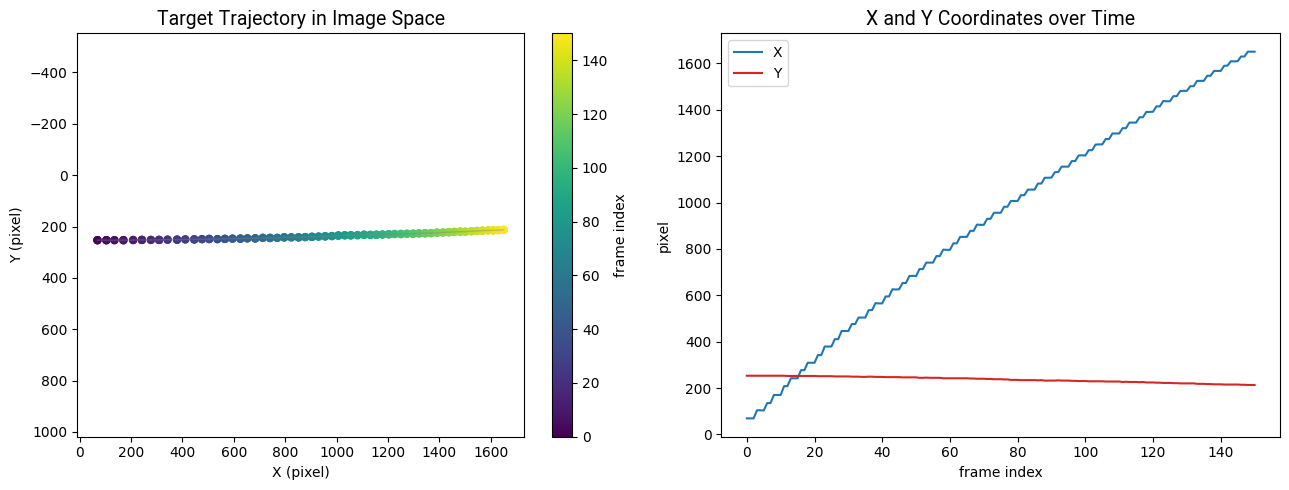

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

font_prop = fm.FontProperties(fname="/content/Vazirmatn.ttf")

def persian_text(text):
    return get_display(arabic_reshaper.reshape(text))

frames_arr = [r[0] for r in trajectory]
xs_arr = [r[1] for r in trajectory]
ys_arr = [r[2] for r in trajectory]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(xs_arr, ys_arr, c=frames_arr, cmap="viridis", s=25)
axes[0].plot(xs_arr, ys_arr, color="gray", alpha=0.4, linewidth=1)
axes[0].invert_yaxis()
axes[0].set_aspect('equal', adjustable='datalim')
axes[0].set_xlabel("X (pixel)")
axes[0].set_ylabel("Y (pixel)")
axes[0].set_title(persian_text("Target Trajectory in Image Space"), fontproperties=font_prop, fontsize=14)
plt.colorbar(sc, ax=axes[0], label="frame index")
axes[1].plot(frames_arr, xs_arr, label="X", color="tab:blue")
axes[1].plot(frames_arr, ys_arr, label="Y", color="tab:red")
axes[1].set_xlabel("frame index")
axes[1].set_ylabel("pixel")
axes[1].set_title(persian_text("X and Y Coordinates over Time"), fontproperties=font_prop, fontsize=14)
axes[1].legend()

plt.tight_layout()
traj_plot_path = "/content/data/trajectory_plot.png"
plt.savefig(traj_plot_path, dpi=150)
plt.show()


# Exporting CSV

In [12]:
import csv

csv_path = "/content/data/trajectory.csv"
with open(csv_path, "w", newline="") as f:
    writer_csv = csv.writer(f)
    writer_csv.writerow(["frame_index", "X", "Y"])
    writer_csv.writerows(trajectory)
